# 1. Configuração e Carregamento de Dados

Nesta seção importamos bibliotecas, mostramos o bloco opcional para download via Kaggle (Colab) e carregamos os arquivos CSV de 2015/2016/2017. Em seguida adicionamos a coluna `year` e concatenamos os três datasets em `df`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")


## 1.1 (Opcional) Download do Kaggle no Colab

Execute apenas se estiver no Google Colab e quiser baixar direto do Kaggle.


In [2]:
username = "COLE_SEU_USERNAME_AQUI"
token = "COLE_SUA_API_KEY_AQUI"

# Criar a pasta .kaggle
os.makedirs("/root/.kaggle", exist_ok=True)

# Criar o arquivo kaggle.json
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump({"username": username, "key": token}, f)

# Ajustar permissões
os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("✔️ kaggle.json criado com sucesso!")

✔️ kaggle.json criado com sucesso!


In [3]:
!kaggle datasets download -d rojour/boston-results
!unzip -o boston-results.zip

Dataset URL: https://www.kaggle.com/datasets/rojour/boston-results
License(s): unknown
  0% 0.00/4.46M [00:00<?, ?B/s]
100% 4.46M/4.46M [00:00<00:00, 747MB/s]
Archive:  boston-results.zip
  inflating: marathon_results_2015.csv  
  inflating: marathon_results_2016.csv  
  inflating: marathon_results_2017.csv  


## 1.2 Carregamento dos Arquivos CSV

Carrega os CSVs já baixados para o Colab (ou locais no seu ambiente).


In [ ]:
# 1. Carregamento dos Datasets
df_15 = pd.read_csv("/content/marathon_results_2015.csv")
df_16 = pd.read_csv("/content/marathon_results_2016.csv")
df_17 = pd.read_csv("/content/marathon_results_2017.csv")

## 1.3 Criar coluna `year` e concatenar DataFrames

Adiciona a coluna `year` em cada DataFrame e concatena todos em `df`.

In [ ]:
# 1.3 Adição da coluna 'year'

df_15['year'] = 2015
df_16['year'] = 2016
df_17['year'] = 2017

# 1.3 Concatenação dos Três Anos
df = pd.concat([df_15, df_16, df_17], ignore_index=True)


## 1.4 Inspeção inicial do DataFrame

Verifica shape, tipos e exibe as primeiras linhas.


In [ ]:
print("Shape final do dataset:", df.shape)
print(df.info())
df.head()


Shape final do dataset: (79638, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79638 entries, 0 to 79637
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     53008 non-null  float64
 1   Bib            79638 non-null  object 
 2   Name           79638 non-null  object 
 3   Age            79638 non-null  int64  
 4   M/F            79638 non-null  object 
 5   City           79637 non-null  object 
 6   State          70645 non-null  object 
 7   Country        79638 non-null  object 
 8   Citizen        3440 non-null   object 
 9   Unnamed: 9     158 non-null    object 
 10  5K             79638 non-null  object 
 11  10K            79638 non-null  object 
 12  15K            79638 non-null  object 
 13  20K            79638 non-null  object 
 14  Half           79638 non-null  object 
 15  25K            79638 non-null  object 
 16  30K            79638 non-null  object 
 17  35K           

,Unnamed: 0,Bib,Name,Age,M/F,City,State,Country,Citizen,Unnamed: 9,...,35K,40K,Pace,Proj Time,Official Time,Overall,Gender,Division,year,Unnamed: 8
0,0.0,3,"Desisa, Lelisa",25,M,Ambo,NaN,ETH,NaN,NaN,...,1:47:59,2:02:39,0:04:56,-,2:09:17,1,1,1,2015,NaN
1,1.0,4,"Tsegay, Yemane Adhane",30,M,Addis Ababa,NaN,ETH,NaN,NaN,...,1:47:59,2:02:42,0:04:58,-,2:09:48,2,2,2,2015,NaN
2,2.0,8,"Chebet, Wilson",29,M,Marakwet,NaN,KEN,NaN,NaN,...,1:47:59,2:03:01,0:04:59,-,2:10:22,3,3,3,2015,NaN
3,3.0,11,"Kipyego, Bernard",28,M,Eldoret,NaN,KEN,NaN,NaN,...,1:48:03,2:03:47,0:05:00,-,2:10:47,4,4,4,2015,NaN
4,4.0,10,"Korir, Wesley",32,M,Kitale,NaN,KEN,NaN,NaN,...,1:47:59,2:03:27,0:05:00,-,2:10:49,5,5,5,2015,NaN


# 2. Limpeza e Pré-processamento de Dados
Nesta etapa convertemos tempos para segundos, tratamos valores inconsistentes, removemos colunas inúteis e ajustamos tipos.



## 2.1 Conversão de Colunas de Tempo para Segundos (HH:MM:SS → Segundos)
Convertimos tempos no formato string para valores numéricos em segundos, essenciais para modelagem.


In [ ]:
# 2.1 Conversão de HH:MM:SS para segundos

def time_to_seconds(t):
    if pd.isna(t):
        return np.nan
    try:
        h, m, s = map(int, t.split(':'))
        return h * 3600 + m * 60 + s
    except:
        return np.nan

# Colunas principais a converter agora
time_cols = ['5K', '10K', '15K', 'Official Time']

for col in time_cols:
    df[col + '_sec'] = df[col].apply(time_to_seconds)


## 2.2 Remoção e Tratamento de Colunas Inconsistentes ou Vazias
Removemos colunas com muitos nulos, renomeamos variáveis, tratamos categorias e eliminamos valores inválidos.


In [ ]:
# 2.2 Limpeza de colunas problemáticas

# Remove colunas inúteis com muitos nulos
df = df.drop(columns=['Unnamed: 0', 'Unnamed: 8', 'Unnamed: 9'], errors='ignore')

# Remove primeiro a coluna numérica
df = df.drop(columns=['Gender'])

# Renomeia M/F para Gender
df = df.rename(columns={'M/F': 'Gender'})

# Converte Gender (agora categórica) para category
df['Gender'] = df['Gender'].astype('category')

# Ajusta Year
df = df.rename(columns={'year': 'Year'})
df['Year'] = df['Year'].astype('category')

# Remover linhas sem City
df = df.dropna(subset=['City'])

# Remover linhas sem tempos essenciais
df = df.dropna(subset=['5K_sec', '10K_sec', '15K_sec'])

# Remover colunas com NaN remanescentes e irrelevantes
df = df.drop(columns=['Citizen', 'State'], errors='ignore')

# Filtrar tempos absurdos (acima de 6 horas)
df = df[df['Official Time_sec'] < 6 * 3600].copy()

print(df.info())


<class 'pandas.core.frame.DataFrame'>
Index: 78977 entries, 0 to 79510
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Bib                78977 non-null  object  
 1   Name               78977 non-null  object  
 2   Age                78977 non-null  int64   
 3   Gender             78977 non-null  category
 4   City               78977 non-null  object  
 5   Country            78977 non-null  object  
 6   5K                 78977 non-null  object  
 7   10K                78977 non-null  object  
 8   15K                78977 non-null  object  
 9   20K                78977 non-null  object  
 10  Half               78977 non-null  object  
 11  25K                78977 non-null  object  
 12  30K                78977 non-null  object  
 13  35K                78977 non-null  object  
 14  40K                78977 non-null  object  
 15  Pace               78977 non-null  object  
 16  Proj Time

# 3. Engenharia de Features (Feature Engineering)

Criação das features de ritmo, velocidade e deltas entre checkpoints para enriquecer o dataset e melhorar a performance dos modelos.


## 3.1 Criação de Ritmo e Velocidade (m/s)

Criamos ritmo (pace) em segundos por metro e velocidade (speed) em metros por segundo para os segmentos de 5K, 10K e 15K.


In [ ]:
# Ritmo (Pace) em segundos por metro (s/m)
df['pace_5k'] = df['5K_sec'] / 5000
df['pace_10k'] = df['10K_sec'] / 10000
df['pace_15k'] = df['15K_sec'] / 15000

# Velocidade (Speed) em metros por segundo (m/s)
df['speed_5k'] = 5000 / df['5K_sec']
df['speed_10k'] = 10000 / df['10K_sec']
df['speed_15k'] = 15000 / df['15K_sec']


## 3.2 Criação de Features Delta (diferença entre segmentos)

Criamos deltas de tempo entre checkpoints para identificar aceleração ou desaceleração dos atletas.

In [ ]:
# Delta 5K → 10K
df['delta_5k_10k'] = df['10K_sec'] - df['5K_sec']

# Delta 10K → 15K
df['delta_10k_15k'] = df['15K_sec'] - df['10K_sec']


## 3.3 Codificação de Variáveis Categóricas

Transformamos variáveis categóricas em códigos numéricos para permitir o uso nos modelos de Machine Learning.


In [ ]:
# Codificação de variáveis categóricas
df['Gender'] = df['Gender'].cat.codes
df['Country'] = df['Country'].astype('category').cat.codes

## 3.4 Remoção Final de Colunas para Modelagem

Removemos colunas textuais, identificadores únicos e tempos originais em string para evitar vazamento e garantir coerência no dataset de treino.


In [ ]:
# Remoção de identificadores e textos
df = df.drop(columns=['City', 'Name', 'Bib'], errors='ignore')

# Remoção das colunas originais de tempo (strings)
time_cols_to_drop = [
    '5K','10K','15K','20K','Half','25K','30K','35K','40K',
    'Pace','Proj Time','Official Time'
]
df = df.drop(columns=time_cols_to_drop, errors='ignore')

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 78977 entries, 0 to 79510
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Age                78977 non-null  int64   
 1   Gender             78977 non-null  int8    
 2   Country            78977 non-null  int8    
 3   Overall            78977 non-null  int64   
 4   Division           78977 non-null  int64   
 5   Year               78977 non-null  category
 6   5K_sec             78977 non-null  float64 
 7   10K_sec            78977 non-null  float64 
 8   15K_sec            78977 non-null  float64 
 9   Official Time_sec  78977 non-null  int64   
 10  pace_5k            78977 non-null  float64 
 11  pace_10k           78977 non-null  float64 
 12  pace_15k           78977 non-null  float64 
 13  speed_5k           78977 non-null  float64 
 14  speed_10k          78977 non-null  float64 
 15  speed_15k          78977 non-null  float64 
 16  delta_5k_

# 4. Análise Exploratória de Dados (EDA)

Visualização das distribuições, correlações e relações entre as variáveis de tempo e o alvo (*Official Time_sec*).


## 4.1 Distribuição do Tempo Oficial

Histograma para entender a distribuição do tempo final dos atletas.


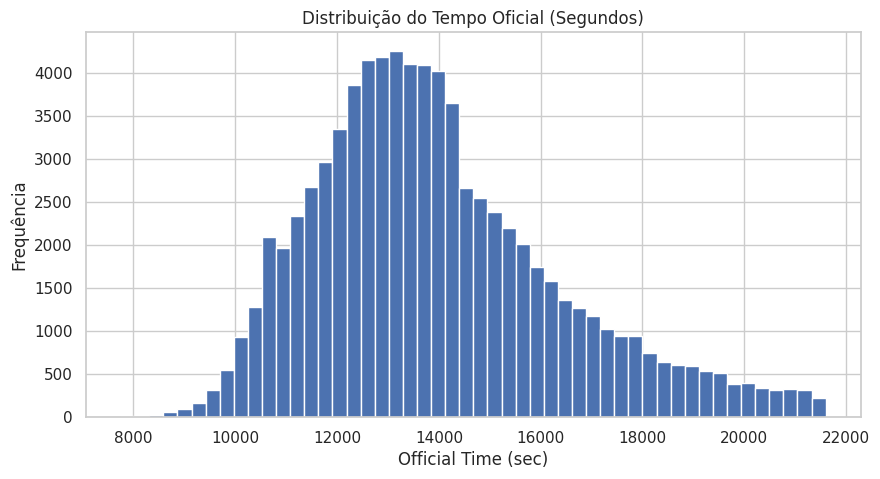

In [ ]:
# Histograma do Tempo Oficial
plt.figure(figsize=(10, 5))
plt.hist(df['Official Time_sec'], bins=50)
plt.title('Distribuição do Tempo Oficial (Segundos)')
plt.xlabel('Official Time (sec)')
plt.ylabel('Frequência')
plt.grid(True)
plt.show()


## 4.2 Mapa de Calor da Correlação

Mostra a relação linear entre as principais features e o tempo oficial.


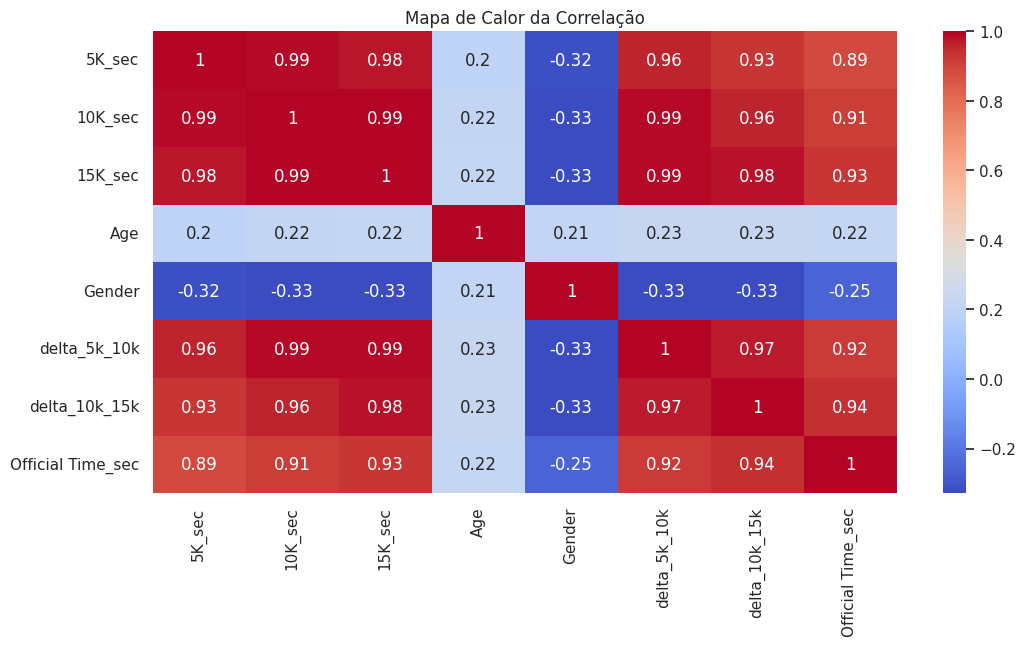

In [ ]:
# Mapa de Calor da Correlação
plt.figure(figsize=(12, 6))
sns.heatmap(
    df[['5K_sec', '10K_sec', '15K_sec',
        'Age', 'Gender',
        'delta_5k_10k', 'delta_10k_15k',
        'Official Time_sec']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Mapa de Calor da Correlação')
plt.show()


## 4.3 Relação entre Tempos Intermediários e o Tempo Oficial

Visualização dos times parciais (5K, 10K, 15K) em relação ao tempo final.


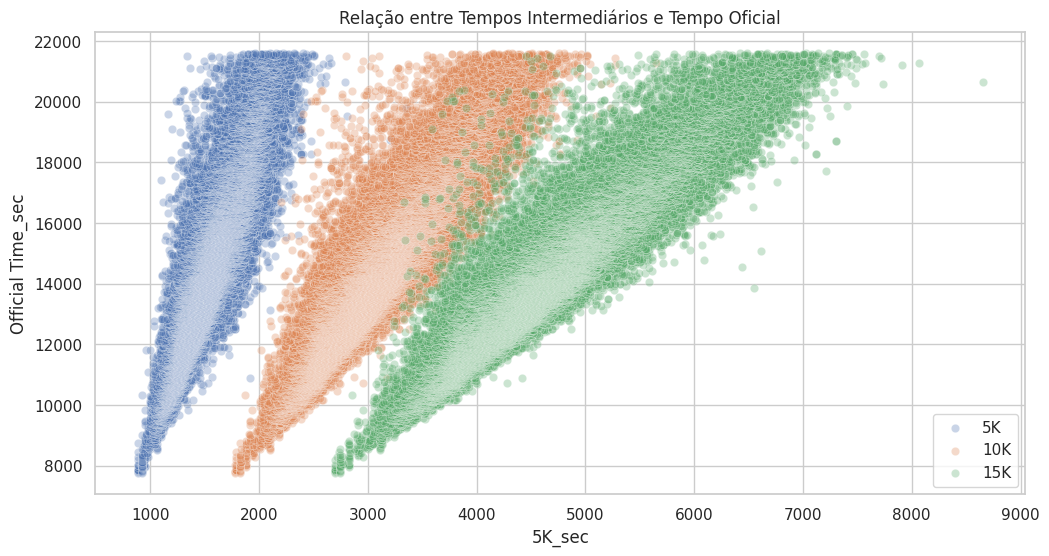

In [ ]:
# Scatter Plots das Variáveis de Tempo vs. Target
plt.figure(figsize=(12, 6))

# 5K vs Official Time
sns.scatterplot(
    x='5K_sec',
    y='Official Time_sec',
    data=df,
    alpha=0.3,
    label='5K'
)

# 10K vs Official Time
sns.scatterplot(
    x='10K_sec',
    y='Official Time_sec',
    data=df,
    alpha=0.3,
    label='10K'
)

# 15K vs Official Time
sns.scatterplot(
    x='15K_sec',
    y='Official Time_sec',
    data=df,
    alpha=0.3,
    label='15K'
)

plt.title('Relação entre Tempos Intermediários e Tempo Oficial')
plt.legend()
plt.show()


# 5. Modelagem e Avaliação

Treinamento dos modelos, cálculo das métricas (MAE, RMSE, R²) e comparação visual do desempenho.


## 5.1 Definição de Features (X) e Target (y)
Selecionamos as variáveis que possuem relação direta com o tempo oficial do atleta.


In [ ]:
# Features para modelagem
features = [
    '15K_sec',
    'Age', 'Gender', 'Country',
    'delta_5k_10k', 'delta_10k_15k',
    'pace_5k', 'pace_10k', 'pace_15k',
    'speed_5k', 'speed_10k', 'speed_15k'
]

X = df[features]
y = df['Official Time_sec']

## 5.2 Divisão em Treino e Teste
Separação do conjunto em 80% treino e 20% teste.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## 5.3 Padronização (Scaling)
A padronização é aplicada somente onde faz sentido (Modelos Lineares).


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5.4 Treinamento dos Modelos e Avaliação
Treinamos 3 modelos: Regressão Linear, Random Forest e XGBoost.
As métricas são armazenadas em um DataFrame para melhor comparação.


In [ ]:
# Dicionário para armazenar métricas
metrics = {
    'Model': [],
    'MAE': [],
    'RMSE': [],
    'R2': [],
    'Train_Time': []
}

### 5.4.1 Modelo 1: Regressão Linear

In [ ]:
start_lin = time.time()

linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)
y_pred_lin = linreg.predict(X_test_scaled)

end_lin = time.time()
train_time_lin = end_lin - start_lin  # tempo total em segundos

mae_lin = mean_absolute_error(y_test, y_pred_lin)
mse_lin = mean_squared_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)
r2_lin = r2_score(y_test, y_pred_lin)

metrics['Model'].append('Linear Regression')
metrics['MAE'].append(mae_lin)
metrics['RMSE'].append(rmse_lin)
metrics['R2'].append(r2_lin)
metrics['Train_Time'].append(train_time_lin)

### 5.4.2 Modelo 2: Random Forest

In [ ]:
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rf_param_distributions = {
    'n_estimators': [150, 200, 250, 300],
    'max_depth': [12, 16, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.7, 1.0]
}

# 2. Configuração do Halving Randomized Search
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_halving_rand = HalvingRandomSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_distributions,
    factor=3,                      # Fator de redução (a cada iteração, usa 3x mais dados)
    resource='n_samples',          # Recurso a ser aumentado (a quantidade de amostras)
    max_resources=X_train.shape[0],# Máximo de amostras (tamanho total do X_train)
    n_candidates=50,               # Inicia com 50 combinações aleatórias (candidatos)
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("\n Iniciando Halving Randomized Search para Random Forest...")
start_rf = time.time()

# 3. Execução da Busca
rf_halving_rand.fit(X_train, y_train)

end_rf = time.time()
train_time_rf = end_rf - start_rf

# 4. Avaliação e Armazenamento dos Resultados
best_rf = rf_halving_rand.best_estimator_

y_pred_rf = best_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\n Melhor conjunto de parâmetros encontrados:")
print(rf_halving_rand.best_params_)

print("\n Tempo total da otimização:", train_time_rf, "segundos")

# Adicionar resultados à tabela (assumindo results_df existe e está no escopo)
new_rf_result = pd.DataFrame({
    'Model': ['Random Forest (Halving Search)'],
    'MAE': [mae_rf],
    'RMSE': [rmse_rf],
    'R2': [r2_rf],
    'Train_Time': [train_time_rf]
})

# results_df = pd.concat([results_df, new_rf_result], ignore_index=True)

print("\n Resultados finais do Random Forest otimizado:")
print(f"MAE:  {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R2:   {r2_rf:.4f}")


 Iniciando Halving Randomized Search para Random Forest...
n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 9
min_resources_: 6
max_resources_: 63181
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 50
n_resources: 6
Fitting 3 folds for each of 50 candidates, totalling 150 fits
----------
iter: 1
n_candidates: 17
n_resources: 18
Fitting 3 folds for each of 17 candidates, totalling 51 fits
----------
iter: 2
n_candidates: 6
n_resources: 54
Fitting 3 folds for each of 6 candidates, totalling 18 fits
----------
iter: 3
n_candidates: 2
n_resources: 162
Fitting 3 folds for each of 2 candidates, totalling 6 fits

 Melhor conjunto de parâmetros encontrados:
{'n_estimators': 250, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': 12}

 Tempo total da otimização: 207.64369702339172 segundos

 Resultados finais do Random Forest otimizado:
MAE:  540.4329
RMSE: 780.8032
R2:   0.8976


### 5.4.3 Modelo 3: XGBoost

In [ ]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
from xgboost import XGBRegressor
import time
import numpy as np

param_distributions = {
    'n_estimators': [300, 500, 700],
    'max_depth': [5, 7, 9],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Modelo base
xgb_base = XGBRegressor(random_state=42, n_jobs=-1)

# Halving Random Search (muito mais rápido)
xgb_halving = HalvingRandomSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    factor=3,
    scoring='neg_mean_squared_error',
    cv=3,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

print("\n Iniciando Halving Random Search para XGBoost...")
start_xgb = time.time()

# Executa a busca
xgb_halving.fit(X_train, y_train)

end_xgb = time.time()
train_time_xgb = end_xgb - start_xgb

print("\n Melhor conjunto de parâmetros encontrados:")
print(xgb_halving.best_params_)

print("\n Tempo total da otimização:", train_time_xgb, "segundos")

# Melhor modelo encontrado
best_xgb = xgb_halving.best_estimator_

# Predições
y_pred_xgb = best_xgb.predict(X_test)

# Métricas
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

# Armazena resultados
metrics['Model'].append('XGBoost (Halving Random Search)')
metrics['MAE'].append(mae_xgb)
metrics['RMSE'].append(rmse_xgb)
metrics['R2'].append(r2_xgb)
metrics['Train_Time'].append(train_time_xgb)

print("\n Resultados finais do XGBoost otimizado:")
print(f"MAE:  {mae_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"R²:   {r2_xgb:.4f}")



 Iniciando Halving Random Search para XGBoost...
n_iterations: 5
n_required_iterations: 5
n_possible_iterations: 9
min_resources_: 6
max_resources_: 63181
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 108
n_resources: 6
Fitting 3 folds for each of 108 candidates, totalling 324 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 108 is smaller than n_iter=10530. Running 108 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


----------
iter: 1
n_candidates: 36
n_resources: 18
Fitting 3 folds for each of 36 candidates, totalling 108 fits
----------
iter: 2
n_candidates: 12
n_resources: 54
Fitting 3 folds for each of 12 candidates, totalling 36 fits
----------
iter: 3
n_candidates: 4
n_resources: 162
Fitting 3 folds for each of 4 candidates, totalling 12 fits
----------
iter: 4
n_candidates: 2
n_resources: 486
Fitting 3 folds for each of 2 candidates, totalling 6 fits

 Melhor conjunto de parâmetros encontrados:
{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

 Tempo total da otimização: 87.7966730594635 segundos

 Resultados finais do XGBoost otimizado:
MAE:  541.2859
RMSE: 780.3097
R²:   0.8978


In [ ]:
# DataFrame final
results_df = pd.DataFrame(metrics)
print(results_df)

               Model         MAE        RMSE        R2  Train_Time
0  Linear Regression  550.285835  791.446195  0.894823    0.028603
1      Random Forest  562.489128  803.588535  0.891571  220.790395
2            XGBoost  538.796875  777.363211  0.898532    3.866272


## 5.5 Comparação dos Modelos
Visualização gráfica do desempenho usando MAE e RMSE.


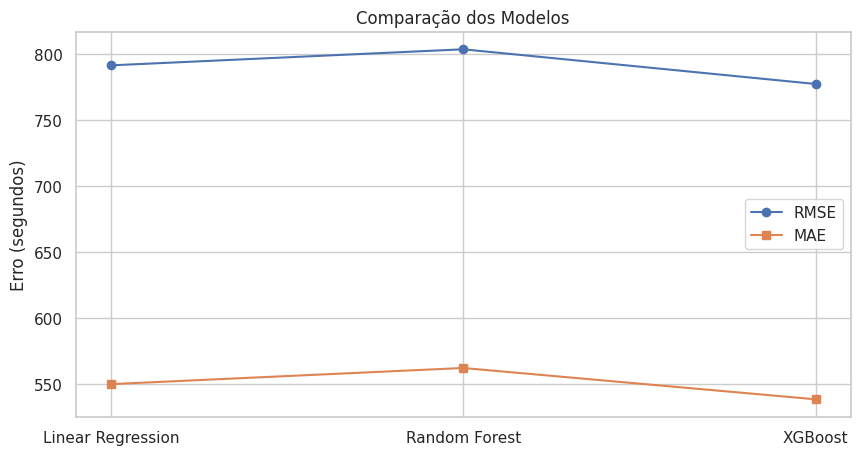

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(results_df['Model'], results_df['RMSE'], marker='o', label='RMSE')
plt.plot(results_df['Model'], results_df['MAE'], marker='s', label='MAE')
plt.title('Comparação dos Modelos')
plt.ylabel('Erro (segundos)')
plt.grid(True)
plt.legend()
plt.show()


# 6. Interpretação dos Resultados e Importância das Features

Nesta seção interpretamos o desempenho dos modelos, identificando qual apresentou melhor performance (menor erro e maior R²) e analisamos quais variáveis mais influenciaram o tempo final do atleta.

Também analisamos a importância das features nos modelos baseados em árvores (Random Forest e XGBoost), que fornecem interpretabilidade nativa.


## 6.1 Interpretação dos Resultados dos Modelos

A tabela de desempenho mostra o erro absoluto médio (MAE), a raiz do erro quadrático médio (RMSE) e o R² para cada modelo.


In [ ]:
results_df

,Model,MAE,RMSE,R2,Train_Time
0,Linear Regression,550.285835,791.446195,0.894823,0.028603
1,Random Forest,562.489128,803.588535,0.891571,220.790395
2,XGBoost,538.796875,777.363211,0.898532,3.866272


### Interpretação

**• XGBoost apresentou o melhor desempenho geral**, com:  
- **Menor MAE** → Erro absoluto médio mais baixo  
- **Menor RMSE** → Erro quadrático médio mais estável  
- **Maior R²** → Melhor capacidade de explicar a variância do tempo oficial  

Isso indica que o XGBoost conseguiu capturar melhor os padrões não lineares entre os tempos intermediários, idade, gênero, deltas e velocidade.


## 6.2 Análise dos Modelos Individualmente

### **6.2.1 Linear Regression — Interpretação**

A Regressão Linear teve um desempenho sólido:

- **MAE ≈ 550s** (≈ 9 min de erro médio)
- **RMSE ≈ 791s**
- **R² = 0.8948**, explicando cerca de **89,5% da variância** do tempo oficial.
- **Tempo de treino: 0.03s**, o mais rápido de todos.

**O que isso significa?**
- A regressão linear funciona bem quando a relação entre variáveis é predominantemente linear.
- Com esse dataset, ela já captura boa parte da dinâmica do tempo final.
- É uma ótima baseline: rápida e eficiente, com erro relativamente baixo.

### **6.2.2 Random Forest — Interpretação**

O Random Forest teve desempenho **ligeiramente inferior** ao da Regressão Linear:

- **MAE ≈ 562s**
- **RMSE ≈ 803s**
- **R² = 0.8916**
- **Tempo de treino: 258s**, **muito mais demorado** devido ao ensemble de 288 árvores.

**Por que piorou um pouco?**
- Random Forest tende a performar melhor com features altamente não lineares.
- Aqui, as diferenças entre checkpoints (5K, 10K, 15K) já têm correlação quase linear perfeita com o tempo final.
- Como os tempos intermediários **dominam fortemente** o comportamento do output, a RF não consegue extrair padrões adicionais.

**Quando a RF seria melhor?**
- Caso tivéssemos muitas variáveis comportamentais, climáticas ou fisiológicas não lineares.


### **6.2.1 XGBoost — Interpretação**

O XGBoost foi o **melhor modelo**:

- **MAE ≈ 539s**
- **RMSE ≈ 777s** (melhor resultado)
- **R² = 0.8985** (melhor explicação da variância)
- **Tempo de treino: 4.46s** (ótimo custo-benefício)

**Por que ele funciona melhor aqui?**
- Captura pequenas não-linearidades entre segmentos.
- Gera interações automáticas entre features, como:
  - aceleração/desaceleração entre splits,
  - padrões de idade × ritmo,
  - diferenças sutis entre homens/mulheres e países.
- É menos propenso a overfitting que a Random Forest quando bem ajustado.

**Conclusão:**  
🔹 **XGBoost entrega o melhor equilíbrio entre performance e tempo de treino.**

## 6.4 Conclusão Geral

- **Os tempos 5K, 10K e 15K explicam a maior parte do resultado.**  
- Isso faz com que **todos os modelos tenham desempenho parecido**, pois a relação é altamente linear.

**Ranking Final:**
1. **XGBoost** (melhor precisão)
2. **Linear Regression** (rápida e quase tão boa quanto o XGB)
3. **Random Forest** (mais lenta e menos precisa)
